In [ ]:
%pip install scikit-learn

In [ ]:
import pandas as pd
import numpy as np


importing tools to do the train test split, make the pipeline, column transformer to easily convert the categorical and numerical features into onehot encoding and scaling repectively

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

lets load the csv file now

In [ ]:
df=pd.read_csv("bank-additional-full.csv", sep=';')

In [ ]:
df.shape
df.iloc[0]

In [ ]:
df.info()

so there are no missing values at all

In [ ]:
df.duplicated().sum()

there are 12 duplicated rows in here. lets see them

In [ ]:
duplicates = df[df.duplicated]

In [ ]:
duplicates

nothing wrong with the duplicated rows so ill drop them. 

In [ ]:
df=df.drop_duplicates()

In [ ]:
df.shape

now lets see if our data is imbalanced or not 

In [ ]:
df['y']

There are 36537 nos and only 4639 yes'. data is imbalanced

i will handle the imbalanced dataset after splitting; not now. 

In [ ]:
df.describe()

now i will look at the features that we have : 
"age" "job" "marital" "education" "default" "housing" "loan" "contact" "month" "day_of_week" "duration" "campaign" "pdays" "previous" "poutcome" "emp.var.rate" "cons.price.idx" "cons.conf.idx" "euribor3m" "nr.employed" "y"

here duration represents the length of call that happened when the customer was called last time. here we are deciding  which customers to call before making the call. we cannot know the duration of the call before actually making it. 

also it is highly misleading, because the duration with 0 seconds willl always have answer 'no'

therefore we drop duration

In [ ]:
df = df.drop(columns=['duration'])

there are unknown values here. but i will consider them as a separate cztegory rather than removing them or imputing anything else. 

pdays:

In [ ]:
print(df['pdays'].value_counts())

999 pdays means customers were not contacted before. and there are ALOT of them

so what i will do is i will add onemore column named contactedaBefore which will be a binary column. it will have 1 if contacted before else 0 (pdays=999)

In [ ]:
df['contacted_before'] = np.where(df['pdays'] == 999, 0, 1)


after doing this , we have separated the cusstomers into contactedbefore or not. but we need to chnage our og pdays column as well. we will change all the 999 values to 0. and keeping rest of it as it is. so the workflow will look something like: model will look if it was contacted before, from the new added column. if yes, thenn it will look howmany days ago from pdays column

In [ ]:

df['pdays'] = np.where(df['pdays'] == 999, 0, df['pdays'])
df['y'] = df['y'].map({'yes': 1, 'no': 0})



In [ ]:
df.shape


In [ ]:
df.iloc[0]

In [ ]:
df.iloc[-1]


now the given dataset is order chronologically meaning the customers who were called first are literaly placed above. so we will not split the data in random order but instead split as first 80% and last 20%. basically we will train on more ""historical data"". 

also our y is in string format eith yes and no. so we convert it into 1 and 0

In [ ]:

split_index = int(len(df) * 0.8)

train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]


X_train = train_df.drop(columns=['y'])
y_train = train_df['y']

X_test = test_df.drop(columns=['y'])
y_test = test_df['y']

#updating our numeric cols and categorical cols 
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()

print(f"Training Features Shape: {X_train.shape}")
print(f"Testing Features Shape: {X_test.shape}")




using  columntransformer to do one hot encoding to our categorical features. and scale our numeric cols

In [ ]:
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ('num', StandardScaler(), numeric_cols)
])



so now i will make our first pipeline. this will be our baseline. we still havent fixed our imbalanced dataset. so keeping it as our baseline will help us on next steps. 

we splitted dataset into 80-20 ratio. 

we added a contacted_before column to our dataframe. we converted string y into binary 1 and 0. 

we made a preprocessor to convert the categorical into one hot encode and numeric into proper scaling. 

In [ ]:
from sklearn.linear_model import LogisticRegression


baseline_model = Pipeline([
    ('preprocessor', preprocessor),
  
    ('classifier', LogisticRegression(max_iter=1000, random_state=42)) 
])


baseline_model.fit(X_train, y_train)

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, average_precision_score


y_pred = baseline_model.predict(X_test)


y_prob = baseline_model.predict_proba(X_test)[:, 1] 


print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report (Precision, Recall, F1):")
print(classification_report(y_test, y_pred))

print(f"\nROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")
print(f"PR-AUC Score (Average Precision): {average_precision_score(y_test, y_prob):.4f}")

lr_ranking = pd.DataFrame({'Actual': y_test, 'Prob': y_prob}).sort_values(by='Prob', ascending=False)
lr_top500 = lr_ranking.head(500)
lr_subscribers = lr_top500['Actual'].sum()
base_rate = y_test.mean() 
print(f"\nSubscribers in Top 500: {lr_subscribers} / 500")
print(f"Precision@500: {lr_subscribers / 500:.4f}")
print(f"Lift@500: {(lr_subscribers / 500) / base_rate:.2f}x")

yes its terrible. since more nos are there in our dataset, it highly biased there. giving high recall and high f1 for class 0. 

now we will add class weight=balanced in our logistic regression model and see where that takes us. 

In [ ]:

balanced_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)) 
])

balanced_model.fit(X_train, y_train)


y_pred_bal = balanced_model.predict(X_test)
y_prob_bal = balanced_model.predict_proba(X_test)[:, 1]



print("--- Balanced Model Evaluation ---")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_bal))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_bal))
print(f"\nROC-AUC Score: {roc_auc_score(y_test, y_prob_bal):.4f}")
print(f"PR-AUC Score (Average Precision): {average_precision_score(y_test, y_prob_bal):.4f}")

so it is catching the yes now because of our penalty but its givin too much yes making our precision down. 

lets see precision@500 and lift@500

In [ ]:



base_rate = y_test.mean() 
expected_random_subscribers = base_rate * 500

print("1. Baseline (Blind Luck)")
print(f" this is base rate{base_rate:.4f}")
print(f"If a call center dialed 500 random people, they'd find ~{expected_random_subscribers:.1f} subscribers.\n")



ranking_df = pd.DataFrame({
    'Actual_Answer': y_test,
    'Probability_Score': y_prob_bal # Probabilities from the balanced model
})

ranking_df = ranking_df.sort_values(by='Probability_Score', ascending=False)


top_500_leads = ranking_df.head(500)


actual_subscribers_found = top_500_leads['Actual_Answer'].sum()
precision_at_500 = actual_subscribers_found / 500


lift_at_500 = precision_at_500 / base_rate

print(" 2. Our Balanced Model's Performance ")
print(f"Subscribers found in Top 500 calls: {actual_subscribers_found}")
print(f"Precision@500: {precision_at_500:.4f}")
print(f"Lift@500: {lift_at_500:.2f}x")
print(f"(This means our model is {lift_at_500:.2f} times more effective than calling at random!)")

so we can conclude that our baseline model has got around 301 subscribers out of 500.

so now we know what this simple logistic regression with balanced data can give us. now we will look into other algorithms to see if we can improve from here. 60% is the % to beat.


In [ ]:
from sklearn.ensemble import RandomForestClassifier

 # we start off with random forest. 

rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])


rf_model.fit(X_train, y_train)


y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]


print("Random Forest Evaluation ")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.4f}")
print(f"PR-AUC: {average_precision_score(y_test, y_prob_rf):.4f}")


rf_ranking = pd.DataFrame({'Actual': y_test, 'Prob': y_prob_rf}).sort_values(by='Prob', ascending=False)
rf_top500 = rf_ranking.head(500)
rf_subscribers = rf_top500['Actual'].sum()
rf_prec_500 = rf_subscribers / 500
rf_lift_500 = rf_prec_500 / base_rate

print(f"\nSubscribers in Top 500: {rf_subscribers} / 500")
print(f"Precision@500: {rf_prec_500:.4f}")
print(f"Lift@500: {rf_lift_500:.2f}x")

alright alright alright 

we did better here. but not by much. we got 61.80% and its doing 2x better than randomly selecting 500 calls. so yeah. 

In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier

gb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', HistGradientBoostingClassifier(
        class_weight='balanced',
        max_iter=200,
        random_state=42
    ))
])


gb_model.fit(X_train, y_train)


y_pred_gb = gb_model.predict(X_test)
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]



print(" Gradient Boosting Evaluation ")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_gb))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb))
print(f"PR-AUC: {average_precision_score(y_test, y_prob_gb):.4f}")


gb_ranking = pd.DataFrame({'Actual': y_test, 'Prob': y_prob_gb}).sort_values(by='Prob', ascending=False)
gb_top500 = gb_ranking.head(500)
gb_subscribers = gb_top500['Actual'].sum()

print(f"\nSubscribers in Top 500: {gb_subscribers} / 500")
print(f"Precision@500: {gb_subscribers / 500:.4f}")
print(f"Lift@500: {(gb_subscribers / 500) / base_rate:.2f}x")

this performed poorly. boosting is out of question 

-----------------------------------------------------------------------------------------------

so this is what we have tried:
logistic regression without balancinf the dataset
logistic regression with balanaced dataset
random forest(bagging)
histgradientboost(boosting)



 

our base rate was 0.3083.  that means if we pick randomly from our test set only 30.83 percent would be yes. 

our logistic regression moddel without any balancing gave precision@500 : 0.5420 and lift@500 1.76x. that means out of 500 top people only 54.20 % said yes and it only did better 1.76 times than our base rate which is random picking.

then comes our logi reg model with class weight=balanced which gave :

Subscribers found in Top 500 calls: 301
Precision@500: 0.6020
Lift@500: 1.95x
better.


then RANDOM FOREST :

Subscribers in Top 500: 309 / 500
Precision@500: 0.6180
Lift@500: 2.00x
YES BETTER 

then our boosting method: 

Subscribers in Top 500: 234 / 500
Precision@500: 0.4680
Lift@500: 1.52x

(disappointment)

so random forest gave us most no of yes (309) out of 500 top customers. so this is the final model i pick.

In [ ]:
rf_top500.head() # this is the list of top 500 people.

---------------------------------------------------------------------------------------

task 2. 

for defining the unit, since we dont have individual unique customer id we cannot cluster based on that. we simply cannot know how many same customers we have called in our examples. so we will keep it simple and cluster according to contact records( all individual rows). and yes it will include some of repeated customers but we honestly cant do anything about it cause theres no way to identify it. 

lets see about the cleaning. we will for sure drop the indicators columns: "emp.var.rate";"cons.price.idx";"cons.conf.idx";"euribor3m";"nr.employed". if these features are there then its likely they will form clusters based on year they were called. these economic indicators reprersents the situation of economy at that time. 

we will as usual drop duration cols as well. we dont know the duration of a call before making a call...

im kind of one the line to drop campaign or not. campaign is the no of times they are previously called in the current campaign. it doesnt feeel that it will help in making clusters. also the task says "past-campaign variables available at the decision point". 

so im dropping campaign for now. but i need to discuss it more.....

In [ ]:
cols_to_drop = ['duration', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'campaign']

In [ ]:
X_clust = X_train.drop(columns=cols_to_drop, errors='ignore')
num_cols = X_clust.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X_clust.select_dtypes(include=['object']).columns

In [ ]:
num_cols

In [ ]:
cat_cols

preprocessor:

In [134]:
unsup_preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), cat_cols), 
    ('num', StandardScaler(), num_cols)
])


storing our training set in X_matrix:

In [135]:
X_matrix = unsup_preprocessor.fit_transform(X_clust)

now for choosing for the no of clusters im using two methods: elbow method and silhouette. 


elbow method:

In [136]:
from sklearn.cluster import KMeans
inertias = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_matrix)
    inertias.append(kmeans.inertia_)


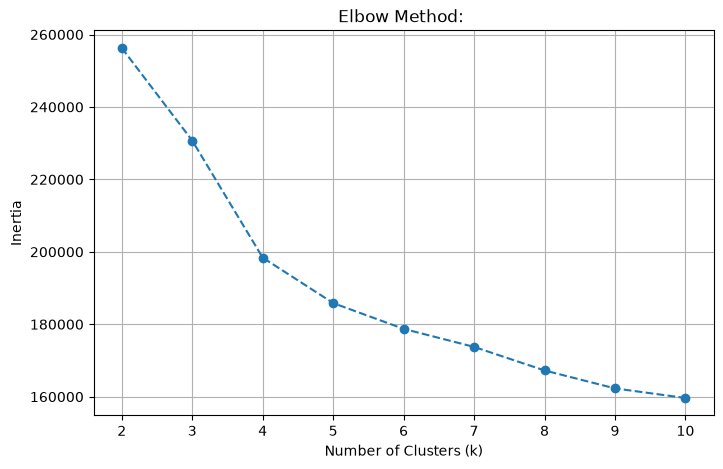

In [137]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, marker='o', linestyle='--')
plt.title('Elbow Method: ')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

so elbow gave me an idea for having clusters 4 or 5. lets see silhouette....

silhouette:

In [138]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

silhouette_scores = []
k_range = range(2, 11)


for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_matrix)
    

    score = silhouette_score(X_matrix, cluster_labels)
    silhouette_scores.append(score)



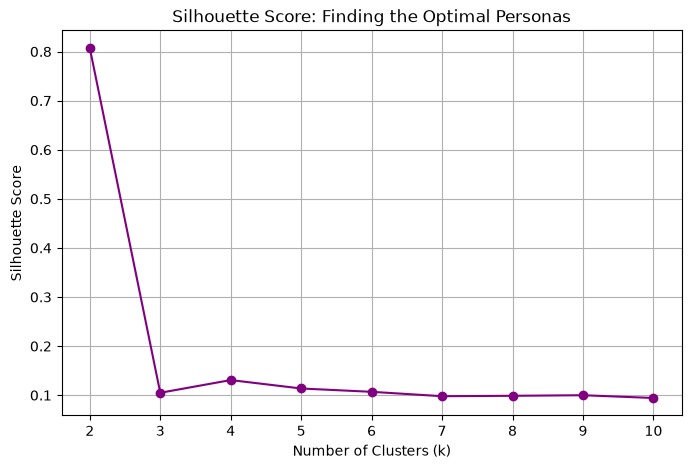

In [139]:

plt.figure(figsize=(8, 5))
plt.plot(k_range, silhouette_scores, marker='o', linestyle='-', color='purple')
plt.title('Silhouette Score: Finding the Optimal Personas')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

very differert observations from both of these. 

elbow method gets consistent after 4 or 5 ig. but silhoutte here gives best as 2. but it feels too immature as 2 clusters will be some obvious choices like previously contacted or not or something similar. but it did showed a little spike at 4, so im gonna go iwith 4.